In [1]:
from google.colab import files
files.upload()

#upload both modules and dataset

{}

In [2]:
!pip install faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 55.9 MB/s eta 0:00:00


In [3]:
import prediction_module as pred
import rag_module as rag
import counterfactual_module as cf
import shap

In [19]:
def generate_simple_llm_output(prediction, confidence, evidence, counterfactual_result):
    final_text = f"""
===== COUNTERSIGHT AI FINAL EXPLANATION =====

Decision Summary:
The loan application was {prediction} with {confidence:.2f}% confidence.
"""

    if prediction == "Rejected":
        final_text += """
This means the model found risk factors in the applicant's profile that reduced the chance of approval.
"""
    else:
        final_text += """
This means the model found the applicant profile suitable for approval.
"""

    final_text += """

Evidence-Based Reasoning:
The system retrieved similar past applicant cases to support the decision.
These examples help compare the current applicant with previous applicants:

"""

    for e in evidence:
        final_text += f"- {e['document']}\n"

    suggestions = counterfactual_result["suggestions"]

    final_text += """

Actionable Suggestions:
"""

    if len(suggestions) == 0:
        final_text += "No major changes are suggested for this applicant.\n"
    else:
        for i, s in enumerate(suggestions, start=1):
            feature = s["feature"]
            current_value = s["current_value"]
            suggested_value = s["suggested_value"]
            priority = s["priority"]
            reason = s["reason"]

            # Make wording natural based on feature
            if feature == "cibil_score":
                action = "Increase CIBIL score"
            elif feature == "loan_amount":
                action = "Reduce loan amount"
            elif feature == "loan_term":
                action = "Reduce loan term"
            else:
                action = f"Change {feature}"

            # Format large numbers with commas
            if isinstance(current_value, (int, float)):
                current_value = f"{current_value:,.0f}"

            if isinstance(suggested_value, (int, float)):
                suggested_value = f"{suggested_value:,.0f}"

            final_text += (
                f"{i}. {action} from {current_value} to {suggested_value}. "
                f"This is a {priority} priority change. "
                f"Reason: {reason}\n"
            )

    final_text += """

Final Summary:
CounterSight AI does not only give an approval or rejection decision.
It explains the decision using similar past cases and gives practical changes that may improve the outcome.
"""

    return final_text

In [20]:
def run_full_pipeline(row_index=0):

    # Prediction
    model, X_train, X_test, y_train, y_test = pred.run_prediction_module()
    sample = X_test.iloc[row_index]

    prob = model.predict_proba(sample.to_frame().T)[0][1]
    prediction = "Approved" if prob > 0.5 else "Rejected"
    confidence = max(prob, 1 - prob) * 100

    #CounterFactual
    applicant_dict = sample.to_dict()

   # print("DEBUG applicant_dict:")
    #print(applicant_dict)
   # print("DEBUG cibil_score:", applicant_dict["cibil_score"], type(applicant_dict["cibil_score"]))

    counterfactual_result = cf.run_counterfactual_module(
        applicant_dict,
        prediction
    )

    # SHAP
    explainer, shap_values = pred.run_shap_module(model, X_train)

    sample_shap_values = explainer(sample.to_frame().T)

    # RAG
    df = rag.load_rag_data()
    stat_docs = rag.create_statistical_documents(df)
    case_docs = rag.create_case_documents(df)
    knowledge_base = rag.build_knowledge_base(stat_docs, case_docs)

    rag_model, embeddings = rag.build_embeddings(knowledge_base)
    index = rag.build_faiss_index(embeddings)

    query_row = df.loc[sample.name]
    query = rag.applicant_to_query(query_row)
    evidence = rag.retrieve_evidence(query, rag_model, index, knowledge_base)

        # Output
    print("\n===== FINAL OUTPUT =====\n")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%\n")

    print("Evidence:")
    for e in evidence:
        print("-", e["document"])

    print("\nCounterfactual Explanation:")
    print(counterfactual_result["readable_output"])

    print("\nSHAP Explanation:")
    shap.plots.waterfall(sample_shap_values[0])

    llm_output = generate_simple_llm_output(
    prediction=prediction,
    confidence=confidence,
    evidence=evidence,
    counterfactual_result=counterfactual_result
    )

    print(llm_output)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== FINAL OUTPUT =====

Prediction: Rejected
Confidence: 99.99%

Evidence:
- Applicant with CIBIL 559, income 9900000, loan 30900000, term 20 months, status Approved.
- Applicant with CIBIL 729, income 4600000, loan 13600000, term 20 months, status Approved.
- Applicant with CIBIL 558, income 7200000, loan 20400000, term 10 months, status Approved.

Counterfactual Explanation:
Counterfactual Suggestions:
These are possible changes that may improve the loan approval outcome.

1. Change: cibil_score
   Current value: 423
   Suggested value: 650
   Priority: High
   Reason: CIBIL score is below the safer approval range. Increasing it may improve approval chances.

2. Change: loan_amount
   Current value: 19700000
   Suggested value: 10800000
   Priority: Medium
   Reason: Loan amount is high compared to annual income. Reducing the requested loan amount may improve approval chances.

3. Change: loan_term
   Current value: 20
   Suggested value: 15
   Priority: Low
   Reason: Loan term i

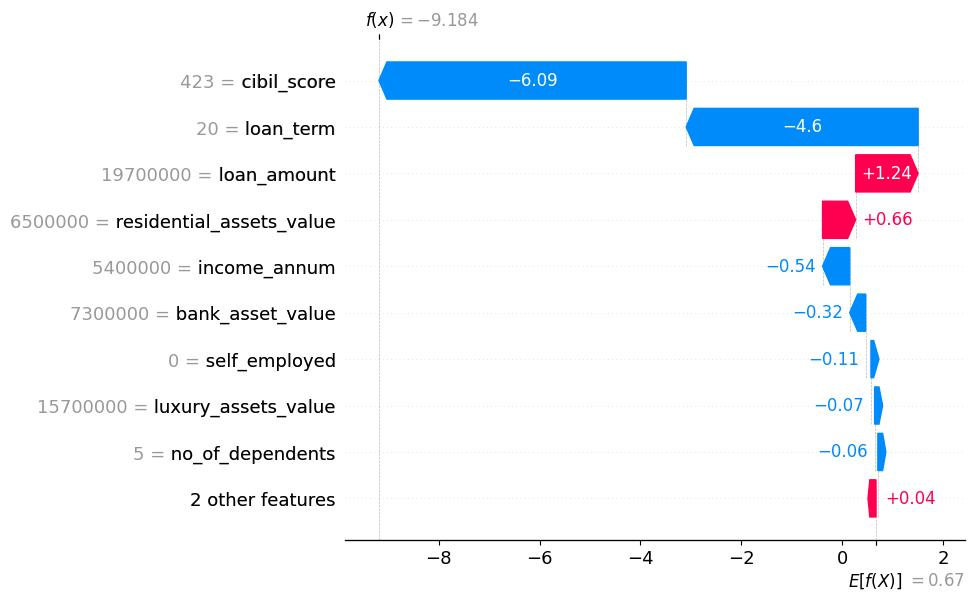


===== COUNTERSIGHT AI FINAL EXPLANATION =====

Decision Summary:
The loan application was Rejected with 99.99% confidence.

This means the model found risk factors in the applicant's profile that reduced the chance of approval.


Evidence-Based Reasoning:
The system retrieved similar past applicant cases to support the decision.
These examples help compare the current applicant with previous applicants:

- Applicant with CIBIL 559, income 9900000, loan 30900000, term 20 months, status Approved.
- Applicant with CIBIL 729, income 4600000, loan 13600000, term 20 months, status Approved.
- Applicant with CIBIL 558, income 7200000, loan 20400000, term 10 months, status Approved.


Actionable Suggestions:
1. Increase CIBIL score from 423 to 650. This is a High priority change. Reason: CIBIL score is below the safer approval range. Increasing it may improve approval chances.
2. Reduce loan amount from 19,700,000 to 10,800,000. This is a Medium priority change. Reason: Loan amount is high co

In [21]:
run_full_pipeline(0)